# UNet FNO – Test-only evaluation

Ez a notebook a **már betanított UNet FNO** modellt értékeli ki a **teszt halmazon**.
Nincs benne tréning, csak:
- path ellenőrzés
- test dataset + dataloader
- checkpoint betöltés
- loss / Dice / IoU számítás
- eredmények mentése
- opcionális vizualizáció


In [ ]:
# Ha most indítottad újra a runtime-ot, mountold a Drive-ot.
# Ha már mountolva van, ezt a cellát hagyd ki.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import random
from dataclasses import dataclass

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Adat gyökér
root_path = "/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test"

# Ide mentünk mindent az UNet FNO-hoz
output_root = "/content/drive/MyDrive/Brain MRI/Unet_FNO_2"

@dataclass
class Config:
    # seedek
    seed_global: int = 42
    seed_split: int = 123

    # tréning
    batch_size: int = 4
    num_epochs: int = 100
    lr: float = 1e-3
    weight_decay: float = 1e-5
    num_workers: int = 2
    val_ratio: float = 0.2
    evals_per_epoch: int = 4

    # warmup + scheduler
    use_warmup: bool = True
    warmup_epochs: int = 5
    warmup_start_lr: float = 1e-5
    scheduler_type: str = "cosine"  # "cosine" vagy "none"
    eta_min: float = 1e-5           # cosine min lr

    # képméret, osztályok
    image_height: int = 256
    image_width: int = 256
    num_classes: int = 2

    # loss
    loss_bce_weight: float = 0.5
    loss_dice_weight: float = 0.5
    loss_smooth: float = 1.0

    # pathok
    model_dir: str = os.path.join(output_root, "models")
    plots_dir: str = os.path.join(output_root, "plots")
    preds_dir: str = os.path.join(output_root, "predictions")
    image_dir: str = os.path.join(root_path, "images")
    mask_dir: str = os.path.join(root_path, "masks")

cfg = Config()

print("Images dir:", cfg.image_dir, "exists:", os.path.isdir(cfg.image_dir))
print("Masks dir:", cfg.mask_dir, "exists:", os.path.isdir(cfg.mask_dir))

os.makedirs(cfg.model_dir, exist_ok=True)
os.makedirs(cfg.plots_dir, exist_ok=True)
os.makedirs(cfg.preds_dir, exist_ok=True)


Device: cpu
Images dir: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images exists: True
Masks dir: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks exists: True


In [ ]:
def set_seed(seed: int):
    print(f"*** Setting global seed to {seed} ***")
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed_global)


*** Setting global seed to 42 ***


In [ ]:
# Test-only pathok
cfg.image_dir = os.path.join(root_path, "images")
cfg.mask_dir = os.path.join(root_path, "masks")
unet_ckpt = "/content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt"

print("root_path :", root_path)
print("image_dir exists:", os.path.exists(cfg.image_dir), cfg.image_dir)
print("mask_dir  exists:", os.path.exists(cfg.mask_dir), cfg.mask_dir)
print("ckpt exists     :", os.path.exists(unet_ckpt), unet_ckpt)

assert os.path.exists(cfg.image_dir), f"Image dir not found: {cfg.image_dir}"
assert os.path.exists(cfg.mask_dir), f"Mask dir not found: {cfg.mask_dir}"
assert os.path.exists(unet_ckpt), f"Checkpoint not found: {unet_ckpt}"


root_path : /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test
image_dir exists: True /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images
mask_dir  exists: True /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks
ckpt exists     : True /content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt


In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir: str, mask_dir: str):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))
        ])
        self.mask_files = sorted([
            f for f in os.listdir(mask_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))
        ])

        if len(self.image_files) == 0:
            raise ValueError(f"Nincs kép a(z) {image_dir} mappában!")
        if len(self.mask_files) == 0:
            raise ValueError(f"Nincs maszk a(z) {mask_dir} mappában!")
        assert len(self.image_files) == len(self.mask_files), \
            "A képek és maszkok száma nem egyezik!"

        print(f"Találtam {len(self.image_files)} képet és maszkot.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        image = image.resize((cfg.image_width, cfg.image_height))
        mask = mask.resize((cfg.image_width, cfg.image_height), Image.NEAREST)

        image = np.array(image, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.int64)
        mask = (mask > 127).astype(np.int64)  # 0 = background, 1 = tumor

        image = np.expand_dims(image, axis=0)  # (1, H, W)

        return torch.from_numpy(image), torch.from_numpy(mask)


In [ ]:
@torch.jit.script
def compl_mul2d(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    # (batch, in_channel, x, y), (in_channel, out_channel, x, y) -> (batch, out_channel, x, y)
    return torch.einsum("bixy, ioxy->boxy", a, b)

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfftn(x, dim=[2, 3])

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            device=x.device,
            dtype=torch.cfloat
        )

        out_ft[:, :, :self.modes1, :self.modes2] = \
            compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        x = torch.fft.irfftn(out_ft, s=(x.size(-2), x.size(-1)), dim=[2, 3])
        return x

class FourierLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, modes=4):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=True
        )
        self.conv_fno = SpectralConv2d(in_channels, out_channels, modes, modes)

    def forward(self, x):
        x1 = self.conv(x)
        x2 = self.conv_fno(x)
        return x1 + x2

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, modes=4):
        super().__init__()
        self.net = nn.Sequential(
            FourierLayer(in_ch, out_ch, kernel_size=3, stride=1, padding=1, modes=modes),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            FourierLayer(out_ch, out_ch, kernel_size=3, stride=1, padding=1, modes=modes),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNetFNO(nn.Module):
    def __init__(self, in_channels=1, out_channels=2, modes=4):
        super().__init__()
        # Encoder
        self.down1 = DoubleConv(in_channels, 64, modes=modes)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128, modes=modes)
        self.pool2 = nn.MaxPool2d(2)

        # Bridge
        self.bridge = DoubleConv(128, 256, modes=modes)

        # Decoder
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128, modes=modes)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64, modes=modes)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # encoder
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        # bridge
        b = self.bridge(p2)

        # decoder
        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

# gyors teszt
model_test = UNetFNO(in_channels=1, out_channels=cfg.num_classes, modes=4).to(device)
x_test = torch.randn(4, 1, cfg.image_height, cfg.image_width).to(device)
y_test = model_test(x_test)
print("Model output shape:", y_test.shape)
print("Total params:", sum(p.numel() for p in model_test.parameters()))


Model output shape: torch.Size([4, 2, 256, 256])
Total params: 7895682


In [ ]:
class CombinedBCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.ce_loss = nn.CrossEntropyLoss()

    def dice_loss(self, logits, targets, num_classes=2):
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes=num_classes)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()

        dice_scores = []
        for cls in range(num_classes):
            pred_cls = probs[:, cls, :, :]
            target_cls = targets_one_hot[:, cls, :, :]
            intersection = (pred_cls * target_cls).sum()
            union = pred_cls.sum() + target_cls.sum()
            dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
            dice_scores.append(dice)

        mean_dice = sum(dice_scores) / len(dice_scores)
        return 1.0 - mean_dice

    def forward(self, logits, targets):
        ce_loss = self.ce_loss(logits, targets)
        dice_loss = self.dice_loss(logits, targets, num_classes=logits.size(1))
        return self.bce_weight * ce_loss + self.dice_weight * dice_loss


In [ ]:
def dice_score(logits, targets, num_classes=2):
    preds = torch.argmax(logits, dim=1)
    batch_size = preds.size(0)
    sample_dice_scores = []

    for i in range(batch_size):
        dice_scores = []
        for cls in range(num_classes):
            pred_mask = (preds[i] == cls).float()
            target_mask = (targets[i] == cls).float()
            intersection = (pred_mask * target_mask).sum()
            dice = (2.0 * intersection) / (pred_mask.sum() + target_mask.sum() + 1e-8)
            dice_scores.append(dice.item())
        sample_dice_scores.append(sum(dice_scores) / len(dice_scores))

    return sample_dice_scores

def compute_iou(logits, targets, num_classes=2):
    preds = torch.argmax(logits, dim=1)
    batch_size = preds.size(0)
    sample_iou_scores = []

    for i in range(batch_size):
        ious = []
        for cls in range(num_classes):
            pred_inds = (preds[i] == cls)
            target_inds = (targets[i] == cls)
            intersection = (pred_inds & target_inds).sum().item()
            union = (pred_inds | target_inds).sum().item()
            if union == 0:
                continue
            ious.append(intersection / union)
        if len(ious) == 0:
            sample_iou_scores.append(0.0)
        else:
            sample_iou_scores.append(sum(ious) / len(ious))

    return sample_iou_scores


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses, dices, ious = [], [], []

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        losses.append(loss.item())
        dices.extend(dice_score(logits, masks, num_classes=cfg.num_classes))
        ious.extend(iou_score(logits, masks, num_classes=cfg.num_classes))

    return float(np.mean(losses)), float(np.mean(dices)), float(np.mean(ious))


In [ ]:
# Test dataset + loader
test_dataset = SegmentationDataset(cfg.image_dir, cfg.mask_dir)
test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True
)

print("Number of test samples:", len(test_dataset))
images, masks = next(iter(test_loader))
print("Test batch images:", images.shape)
print("Test batch masks :", masks.shape)


Találtam 860 képet és maszkot.
Number of test samples: 860


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test batch images: torch.Size([4, 1, 256, 256])
Test batch masks : torch.Size([4, 256, 256])


In [ ]:
# Modell betöltése
model = UNetFNO(
    in_channels=1,
    out_channels=cfg.num_classes,
    modes=4
).to(device)

checkpoint = torch.load(unet_ckpt, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded checkpoint from model_state_dict")
    for key in ["epoch", "val_loss", "val_dice", "val_iou"]:
        if key in checkpoint:
            print(f"{key}: {checkpoint[key]}")
else:
    model.load_state_dict(checkpoint)
    print("Loaded checkpoint as raw state_dict")

model.eval()
print("Model loaded successfully.")


Loaded checkpoint from model_state_dict
epoch: 80
val_dice: 0.9253458717043166
val_iou: 0.8876505427688112
Model loaded successfully.


In [ ]:
def iou_score(logits, masks, num_classes=2):
    preds = torch.argmax(logits, dim=1)

    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            ious.append(torch.tensor(1.0))  # ha nincs class → perfect
        else:
            ious.append(intersection / union)

    return ious

In [ ]:
# Kiértékelés
criterion = CombinedBCEDiceLoss(
    bce_weight=cfg.loss_bce_weight,
    dice_weight=cfg.loss_dice_weight,
    smooth=cfg.loss_smooth
)

test_loss, test_dice, test_iou = evaluate(model, test_loader, criterion)

print("\n===== TEST RESULTS =====")
print(f"Test loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test IoU  : {test_iou:.4f}")



===== TEST RESULTS =====
Test loss : 0.0523
Test Dice : 0.9234
Test IoU  : 0.8869


In [ ]:
# Eredmények mentése
import json

os.makedirs(output_root, exist_ok=True)

results = {
    "checkpoint": unet_ckpt,
    "root_path": root_path,
    "image_dir": cfg.image_dir,
    "mask_dir": cfg.mask_dir,
    "num_test_samples": len(test_dataset),
    "test_loss": test_loss,
    "test_dice": test_dice,
    "test_iou": test_iou,
}

results_path = os.path.join(output_root, "unetfno_test_metrics.json")
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved:", results_path)
results


Saved: /content/drive/MyDrive/Brain MRI/Unet_FNO_2/unetfno_test_metrics.json


{'checkpoint': '/content/drive/MyDrive/Brain MRI/FNO_seg/Unet_FNO_2/models/unetfno_run1_best_model.pt',
 'root_path': '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test',
 'image_dir': '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/images',
 'mask_dir': '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/test/masks',
 'num_test_samples': 860,
 'test_loss': 0.052325243489860104,
 'test_dice': 0.9233893613664022,
 'test_iou': 0.8868582248687744}

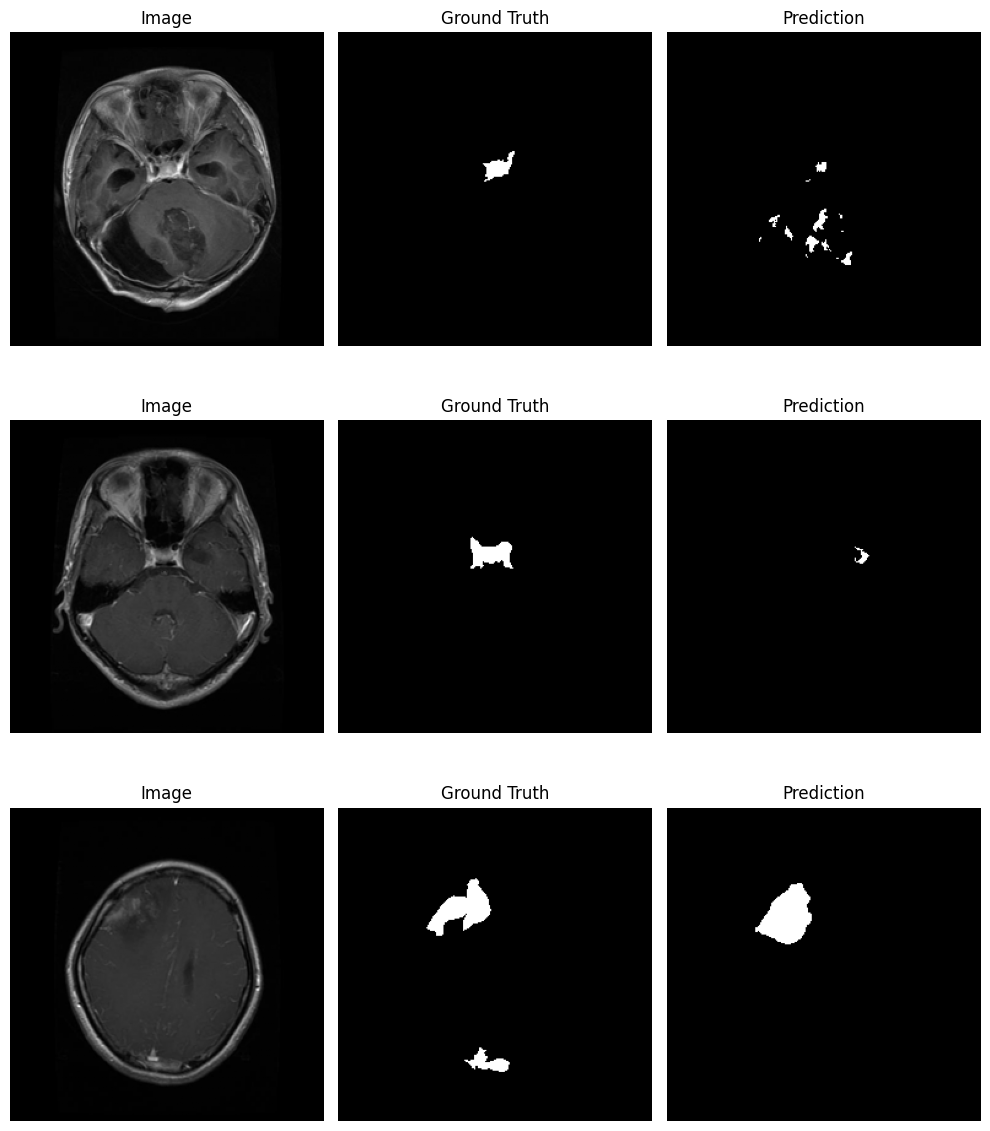

Saved: /content/drive/MyDrive/Brain MRI/Unet_FNO_2/unetfno_test_predictions.png


In [ ]:
# Opcionális vizualizáció
num_visualize = 3
model.eval()

fig, axes = plt.subplots(num_visualize, 3, figsize=(10, 4 * num_visualize))
if num_visualize == 1:
    axes = np.expand_dims(axes, axis=0)

shown = 0
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        for i in range(images.size(0)):
            if shown >= num_visualize:
                break

            img_np = images[i, 0].cpu().numpy()
            mask_np = masks[i].cpu().numpy()
            pred_np = preds[i].cpu().numpy()

            axes[shown, 0].imshow(img_np, cmap="gray")
            axes[shown, 0].set_title("Image")
            axes[shown, 0].axis("off")

            axes[shown, 1].imshow(mask_np, cmap="gray")
            axes[shown, 1].set_title("Ground Truth")
            axes[shown, 1].axis("off")

            axes[shown, 2].imshow(pred_np, cmap="gray")
            axes[shown, 2].set_title("Prediction")
            axes[shown, 2].axis("off")

            shown += 1

        if shown >= num_visualize:
            break

plt.tight_layout()
viz_path = os.path.join(output_root, "unetfno_test_predictions.png")
plt.savefig(viz_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", viz_path)
